In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Cell 1 — Imports & Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

# Load dataset
df = pd.read_csv('../data/phishing.csv')

# First look
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (11054, 32)

First 5 rows:


,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [5]:
# Cell 2 (fixed) — Dataset Inspection

print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nClass distribution:")
print(df.iloc[:, -1].value_counts())  # checks the last column (usually the target)
print("\nMissing values:", df.isnull().sum().sum())
print("\nData types:")
print(df.dtypes.value_counts())

Shape: (11054, 32)

Column names:
 ['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport', 'class']

Class distribution:
class
 1    6157
-1    4897
Name: count, dtype: int64

Missing values: 0

Data types:
int64    32
Name: count, dtype: int64


Class distribution:
class
 1    6157
-1    4897
Name: count, dtype: int64

1 = Legitimate | -1 = Phishing


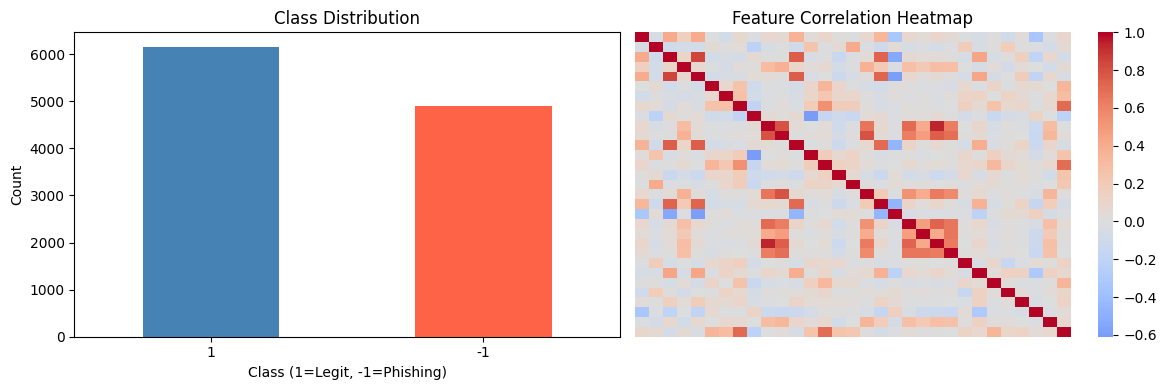

In [6]:
# Cell 3 — EDA

# Fix target column & drop Index
df = df.drop(columns=['Index'])

print("Class distribution:")
print(df['class'].value_counts())
print("\n1 = Legitimate | -1 = Phishing")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 — Class balance
df['class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Class (1=Legit, -1=Phishing)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2 — Correlation heatmap
sns.heatmap(df.corr(), cmap='coolwarm', center=0,
            xticklabels=False, yticklabels=False, ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()